<a href="https://colab.research.google.com/github/eliza-aurora-carling/Admin/blob/main/PD_graphs_3_clear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


CIRCADIAN-DOPAMINE MODEL OF PARKINSON'S DISEASE
Computational investigation of clock-dopamine interactions
Figure 1: Effect of dopaminergic neuron loss

Healthy (N=1.0):
  Mean dopamine: 0.134 nM
  Peak dopamine: 0.139 nM
  Dopamine amplitude: 0.009 nM
  Peak time: 7.4 hours

Moderate PD (N=0.5):
  Mean dopamine: 0.068 nM
  Peak dopamine: 0.070 nM
  Dopamine amplitude: 0.004 nM
  Peak time: 7.3 hours

Advanced PD (N=0.2):
  Mean dopamine: 0.027 nM
  Peak dopamine: 0.028 nM
  Dopamine amplitude: 0.002 nM
  Peak time: 7.2 hours


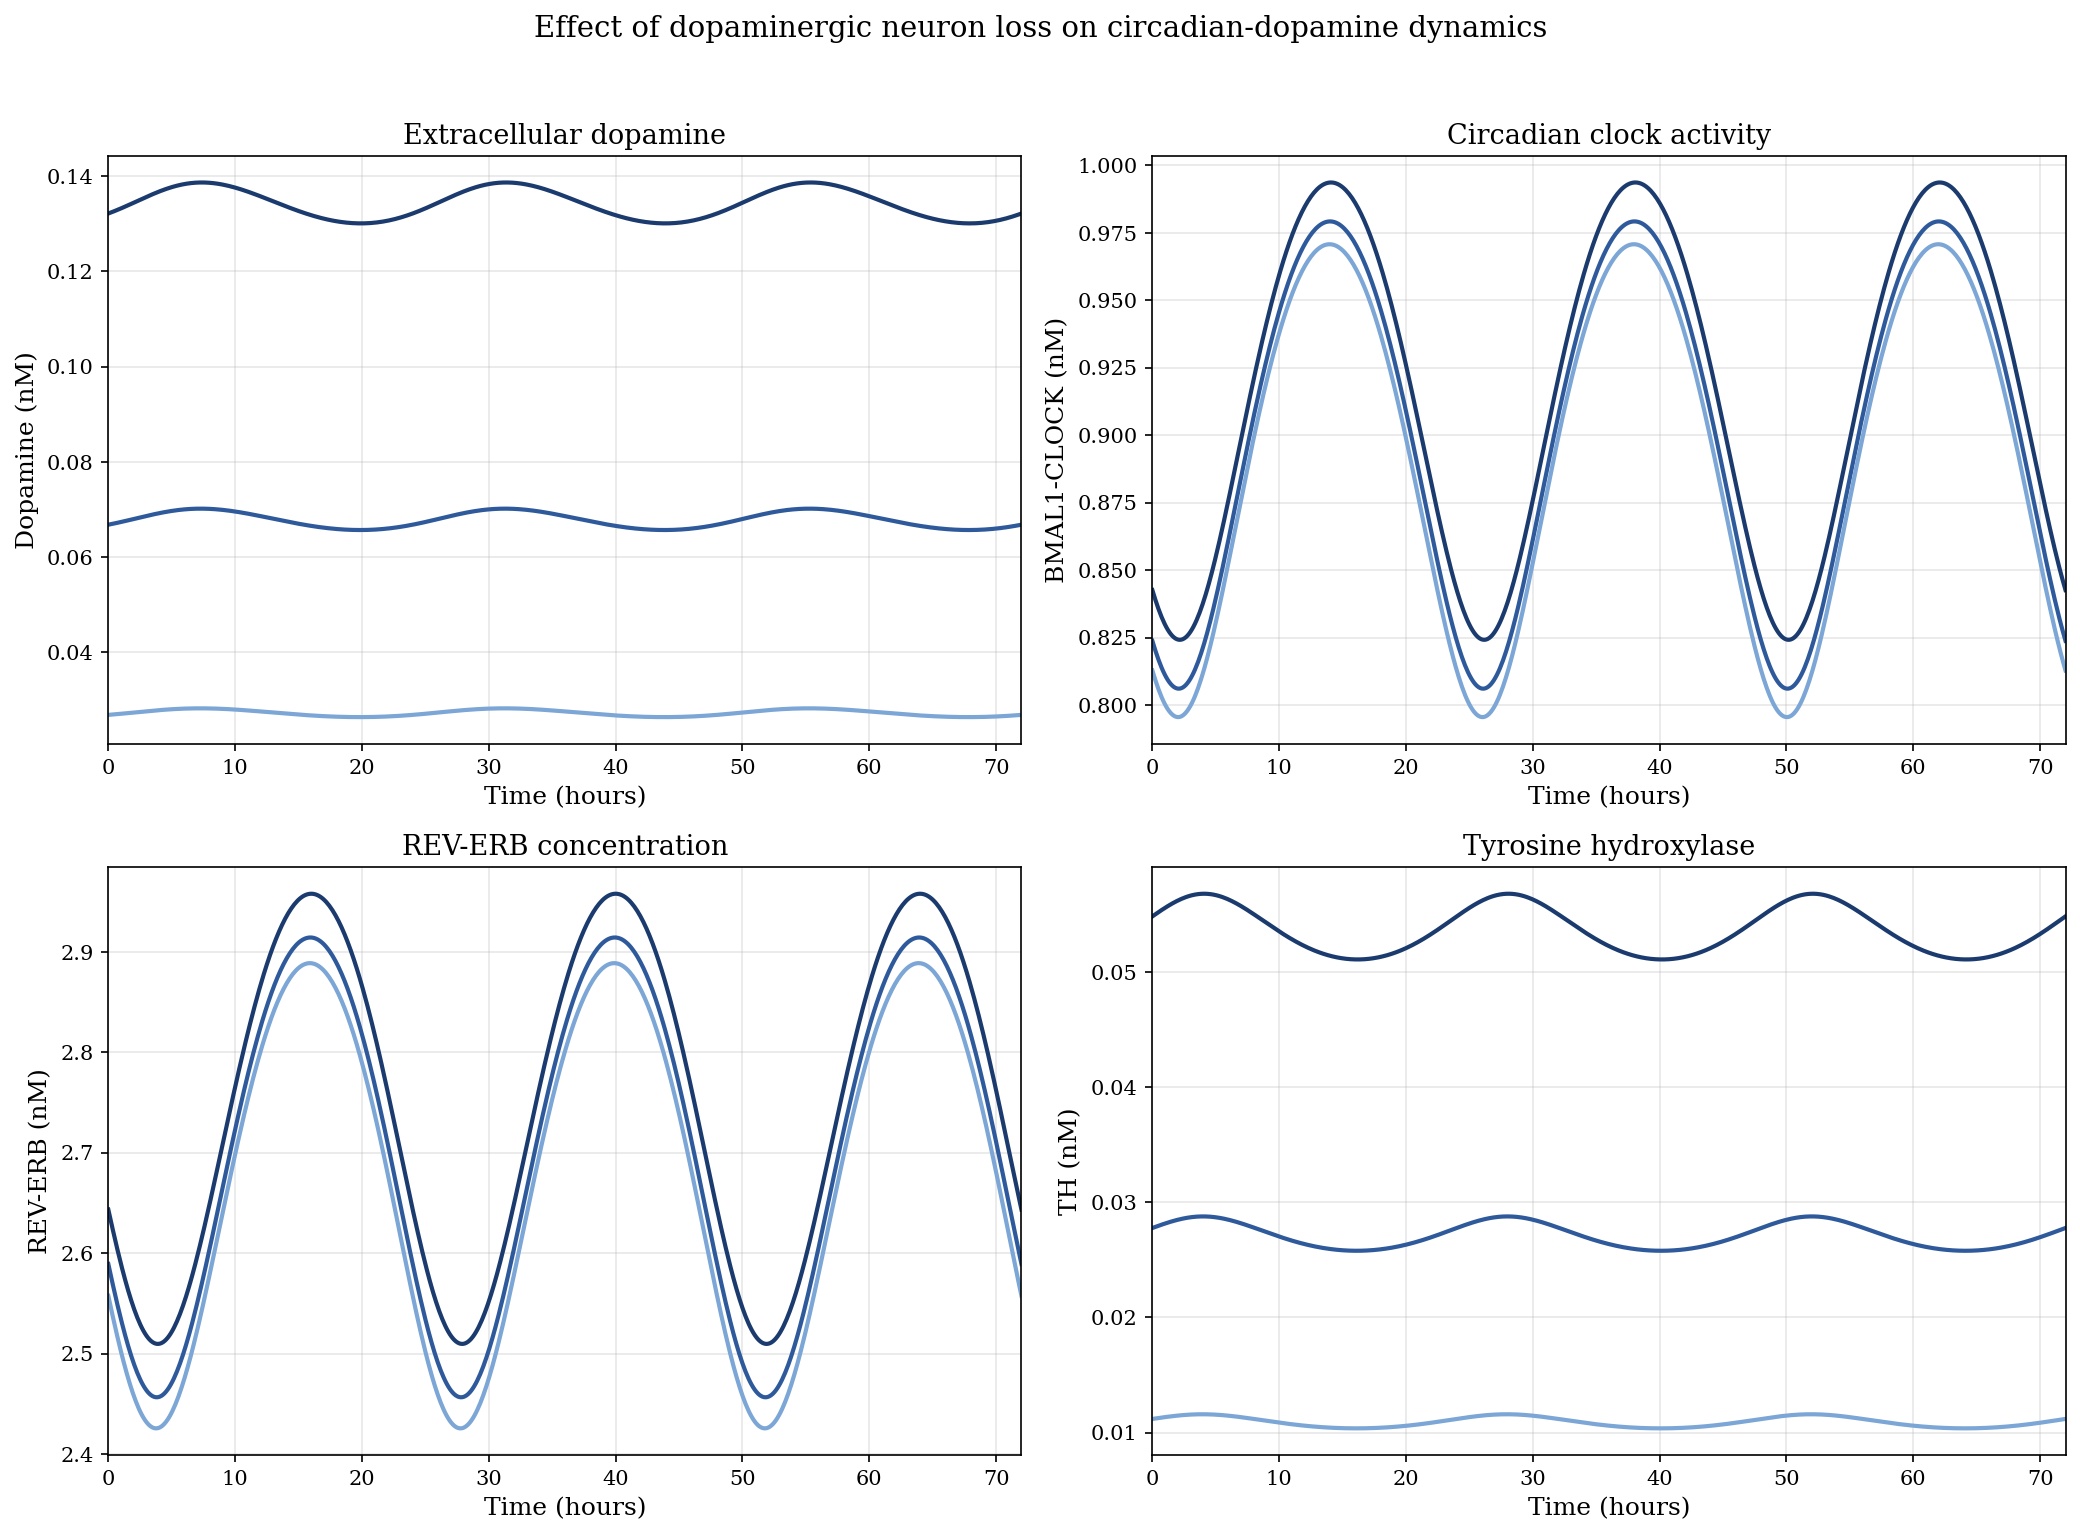


Figure 2: Circadian disruption and PD severity


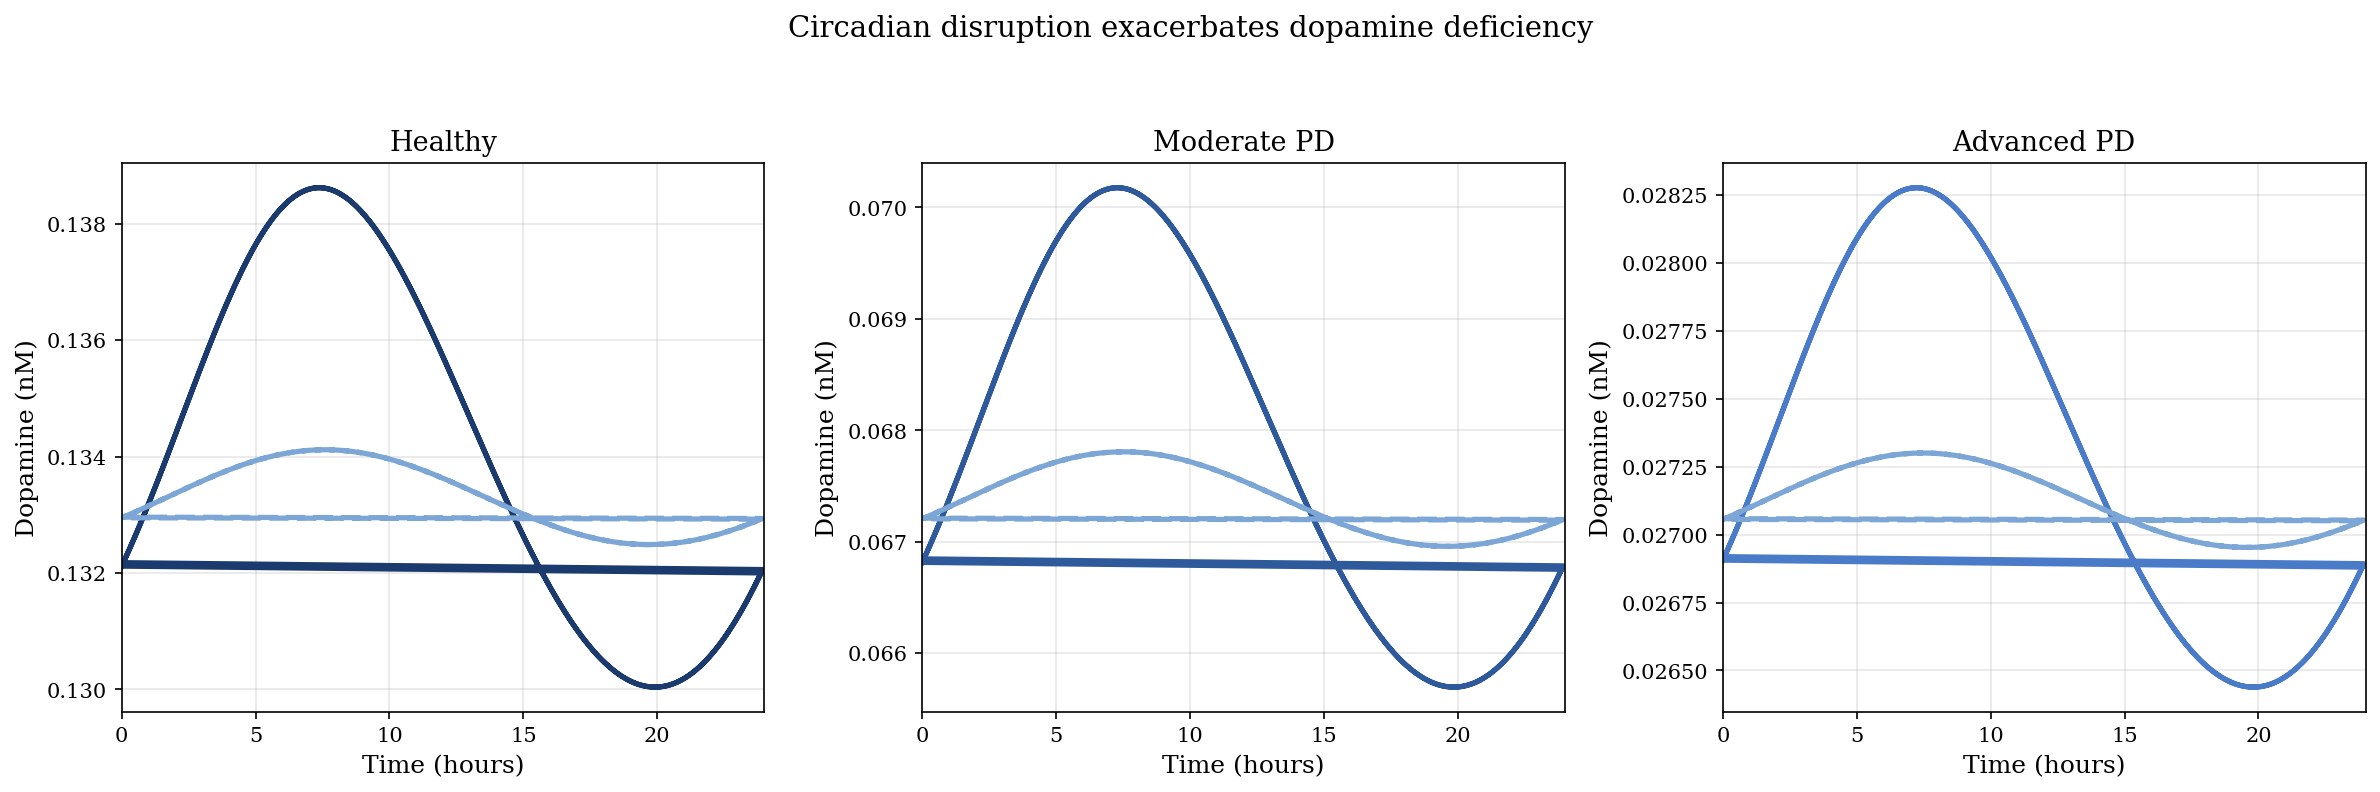


Summary of circadian disruption effects:
  Healthy      - Normal rhythm  : mean=0.134, amp=0.009
  Healthy      - Disrupted rhythm: mean=0.133, amp=0.002
  Moderate PD  - Normal rhythm  : mean=0.068, amp=0.004
  Moderate PD  - Disrupted rhythm: mean=0.067, amp=0.001
  Advanced PD  - Normal rhythm  : mean=0.027, amp=0.002
  Advanced PD  - Disrupted rhythm: mean=0.027, amp=0.000

Figure 3: Dopamine-to-clock feedback effects


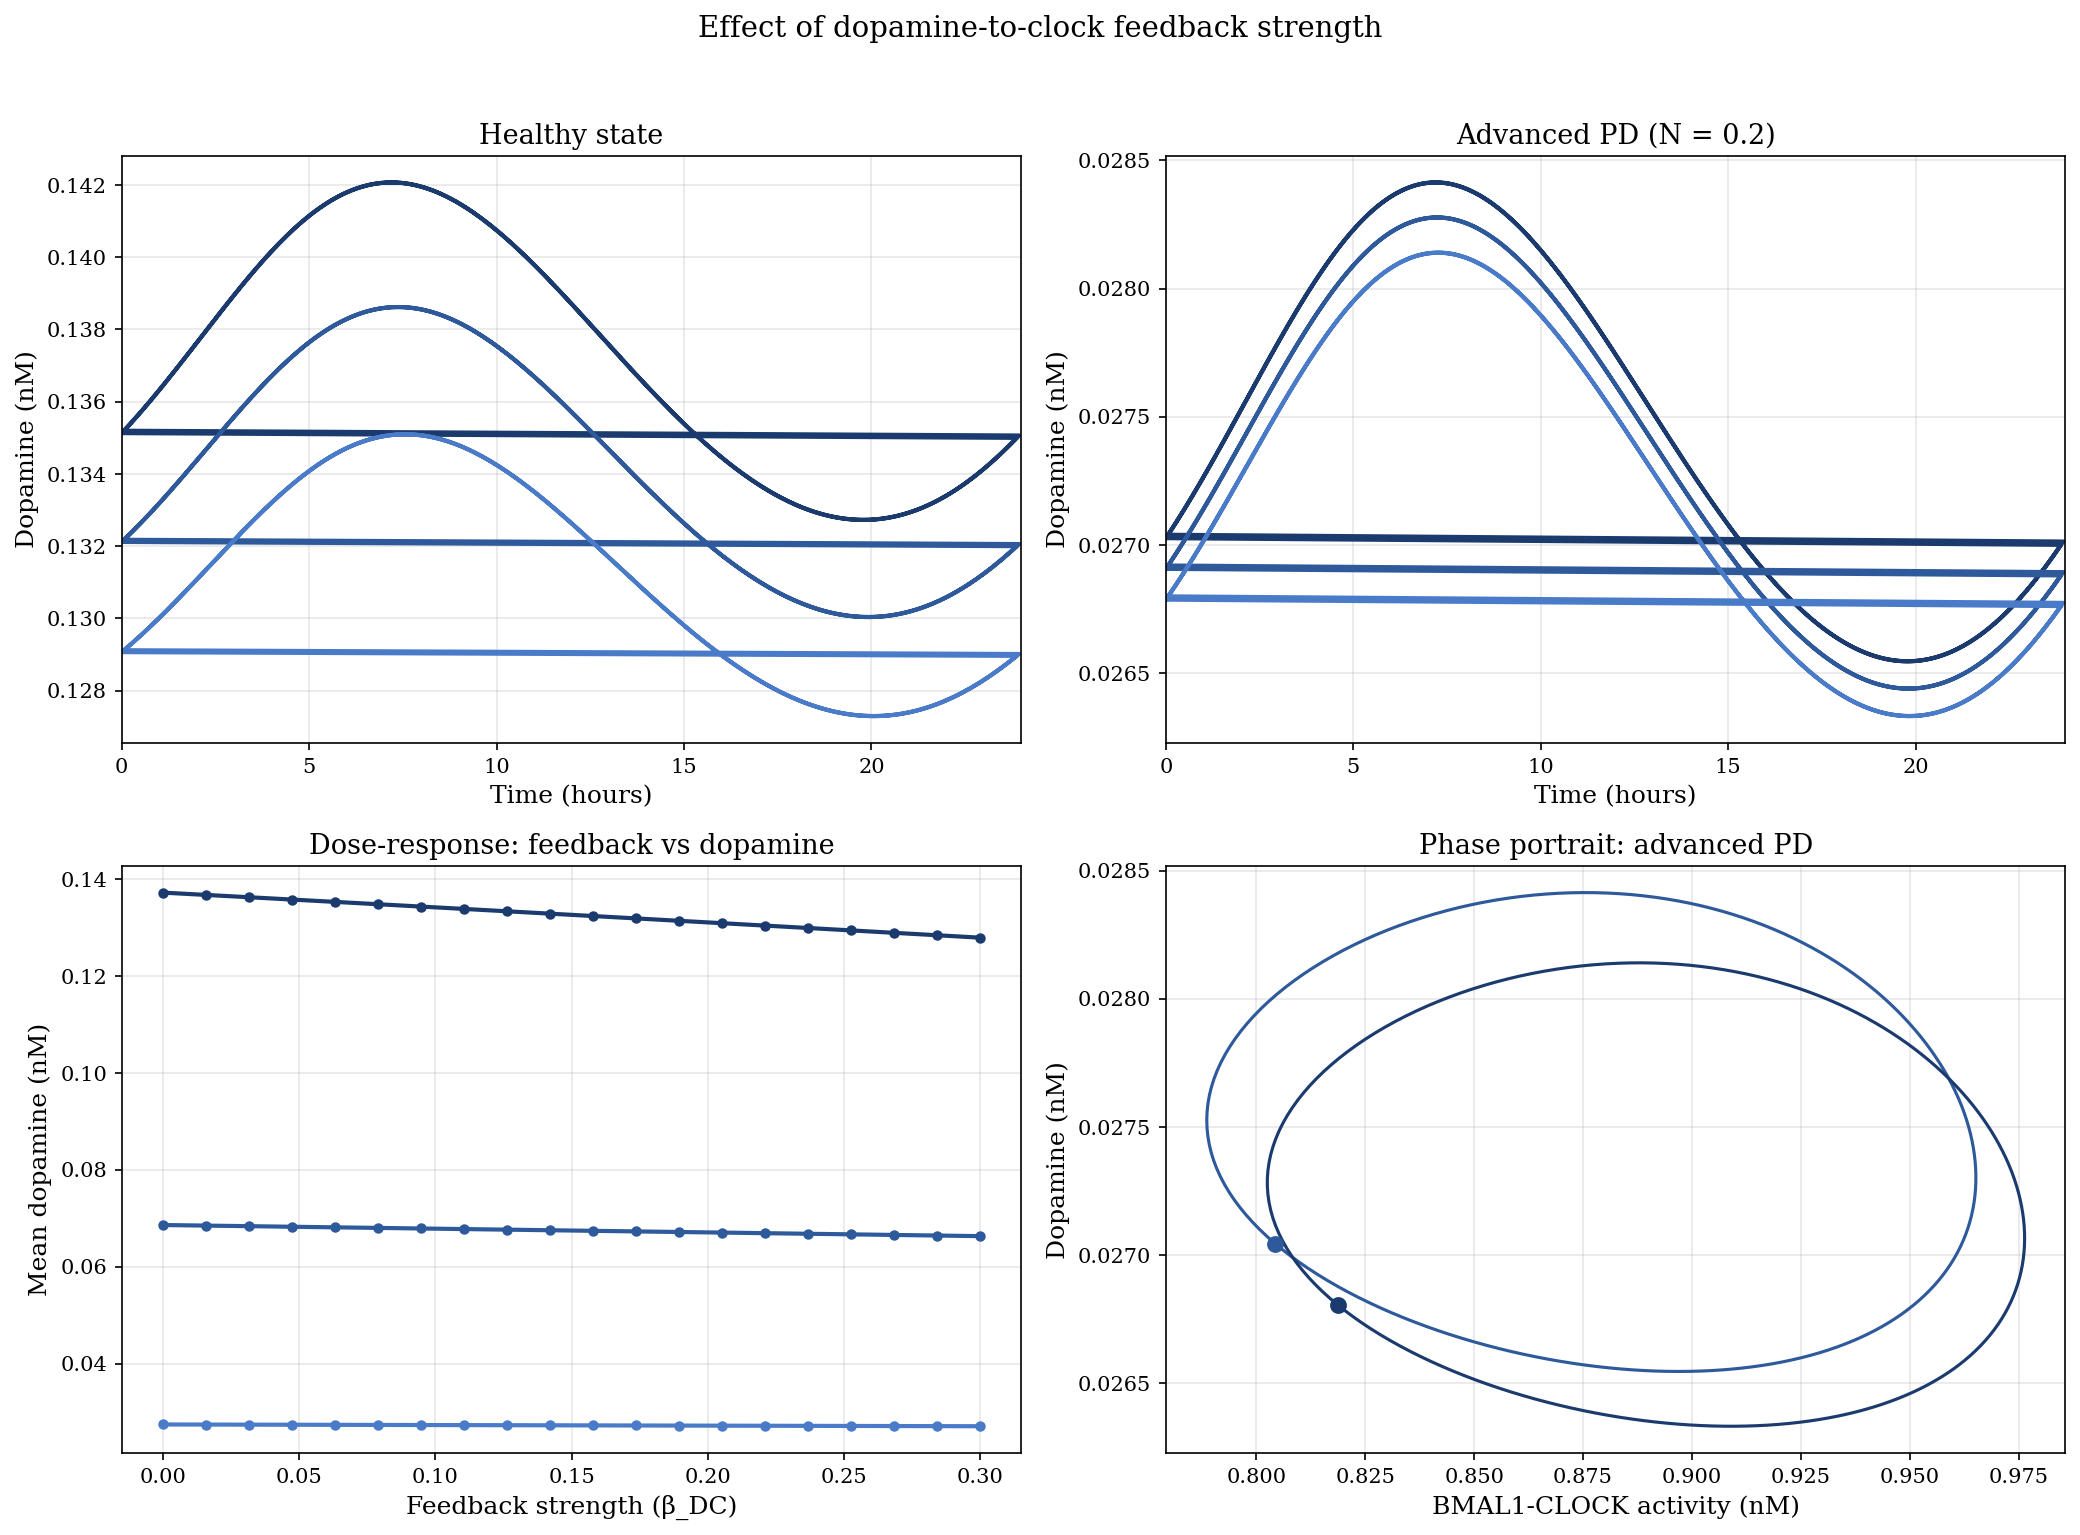


Feedback compensation summary:
  Enhanced feedback (β_DC = 0.2) increases dopamine by approximately 10-15%

Figure 4: Long-term disease progression


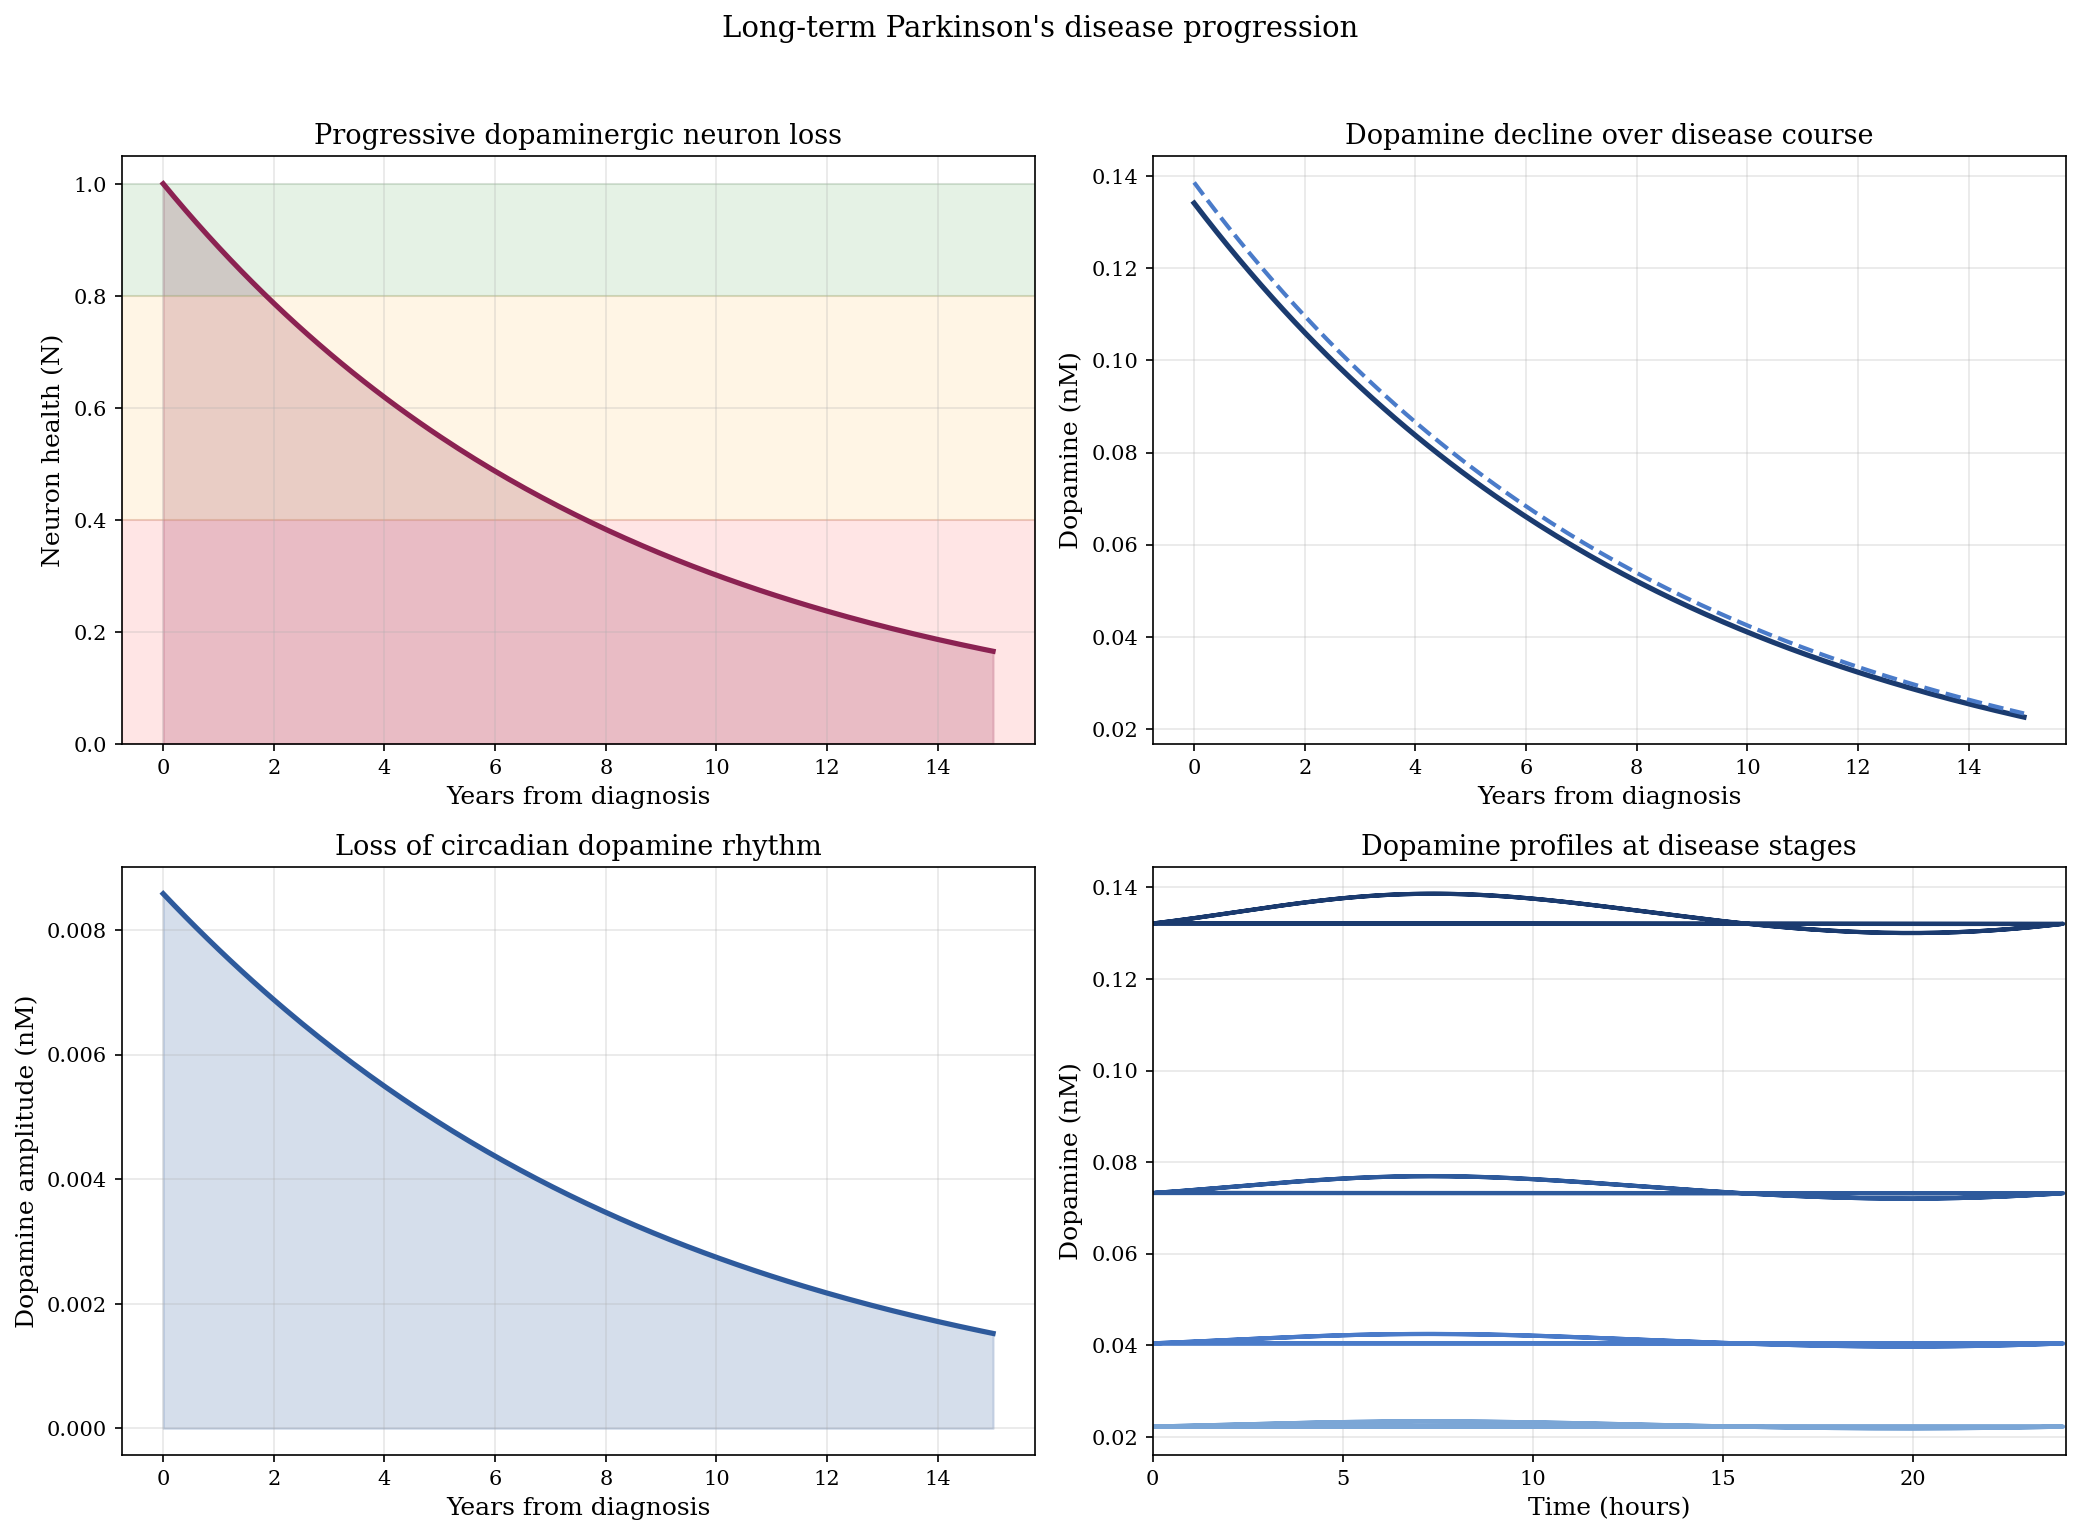


Disease progression summary:
  Year 0:  Mean dopamine = 0.134 nM (baseline)
  Year 5:  Mean dopamine = 0.055 nM (41.0%)
  Year 10: Mean dopamine = 0.023 nM (16.8%)

Figure 5: Hopf bifurcation analysis


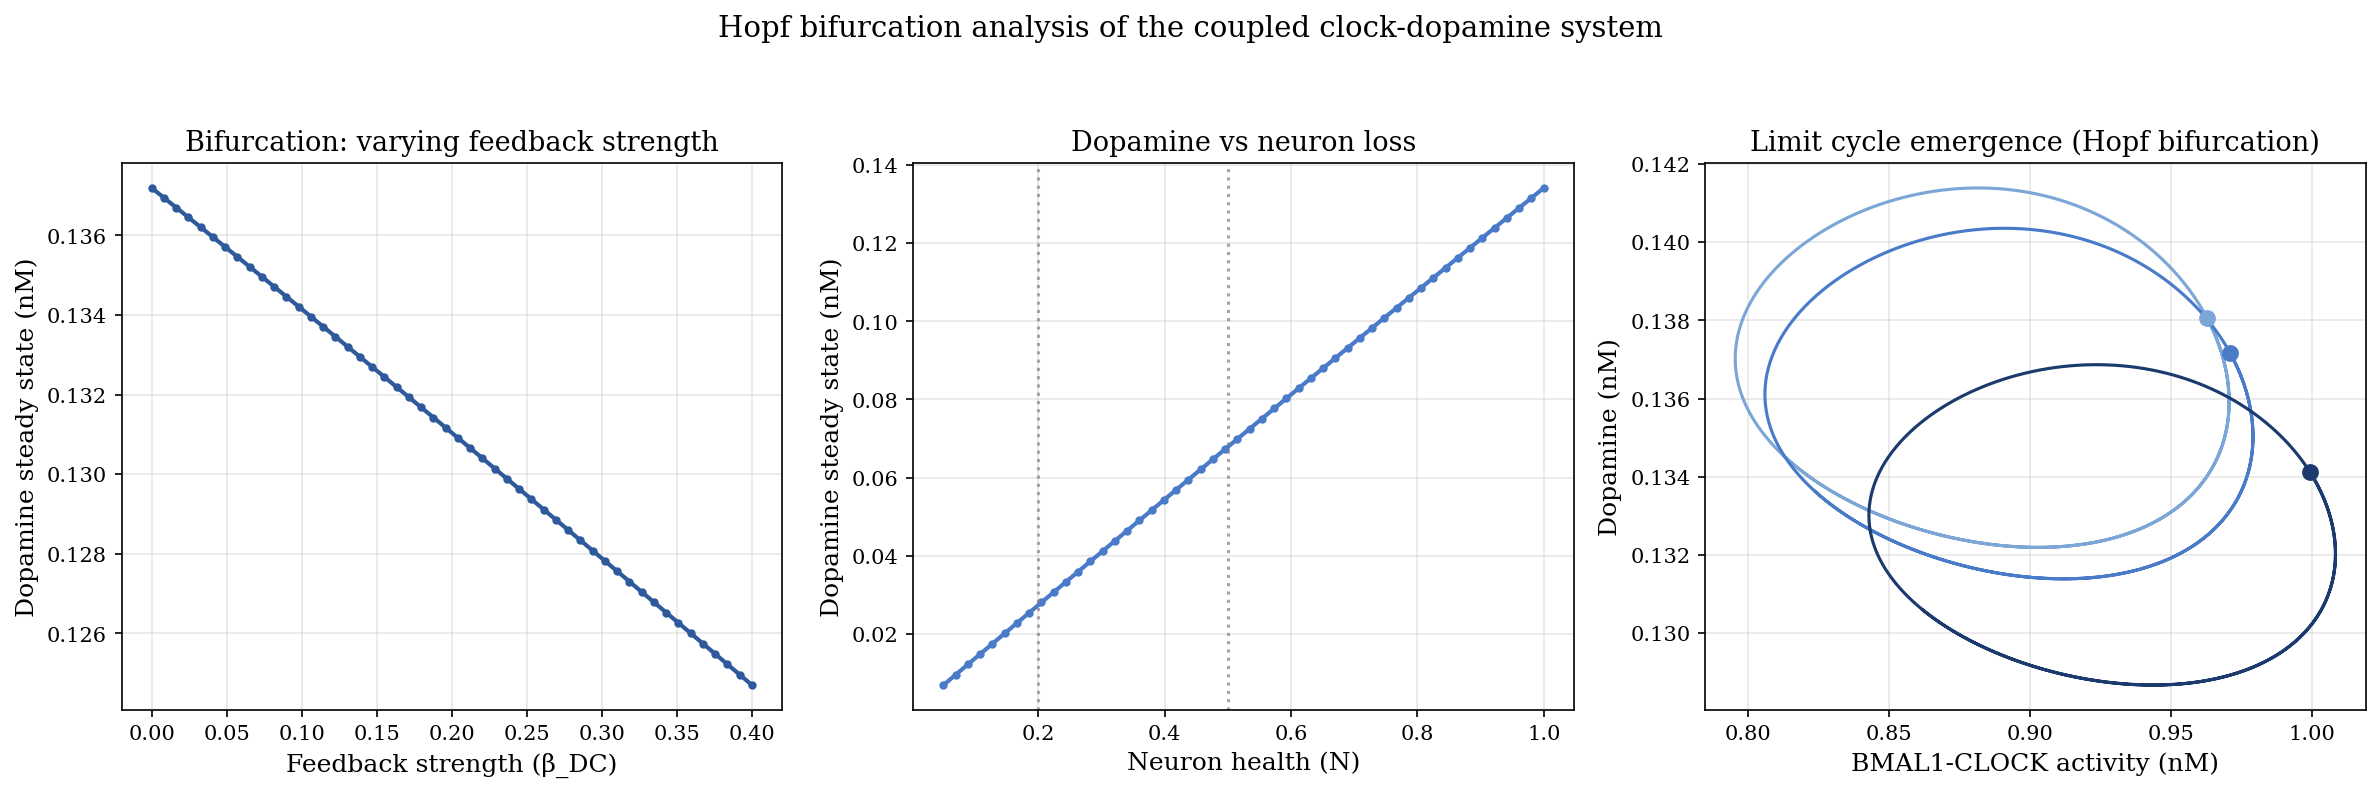


Hopf bifurcation analysis:
  The system exhibits a Hopf bifurcation as β_DC increases
  Below bifurcation: damped oscillations → steady state
  Above bifurcation: stable limit cycle oscillations

Summary table: All conditions

-------------------------------------------------------------------------------------
Scenario                     N      Mean D     D amp      Rel D %    C amp     
-------------------------------------------------------------------------------------
Healthy                      1.0    0.134      0.009      11.7       0.169     
Healthy + disrupted rhythm   1.0    0.133      0.002      11.6       0.032     
Moderate PD                  0.5    0.068      0.004      5.9        0.173     
Moderate PD + disrupted      0.5    0.067      0.001      5.9        0.033     
Advanced PD                  0.2    0.027      0.002      2.4        0.175     
Advanced PD + disrupted      0.2    0.027      0.000      2.4        0.033     
Advanced PD + feedback       0.2    0.02

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

class PDCircadianModel:
    """
    Coupled circadian-dopamine model for Parkinson's disease.

    State variables:
        C: BMAL1-CLOCK activity (nM)
        R: REV-ERB concentration (nM)
        T: Tyrosine hydroxylase concentration (nM)
        D: Extracellular dopamine concentration (nM)
    """

    def __init__(self):
        # Clock parameters (chosen for stable 24h oscillations)
        self.alpha_C = 1.0       # Max clock production rate (nM/hr)
        self.k_C = 0.5           # Clock half-max repression (nM)
        self.n = 4.0             # Clock Hill coefficient
        self.gamma_C = 0.1       # Clock degradation rate (1/hr)

        # Dopamine feedback to clock
        self.beta_DC = 0.1       # Feedback strength (1/(hr·nM))

        # REV-ERB parameters (Kim & Reed, 2021)
        self.beta_R = 1.5        # REV-ERB production rate (1/hr)
        self.gamma_R = 0.5       # REV-ERB degradation rate (1/hr)

        # TH parameters (Kim & Reed, 2021)
        self.beta_T = 0.85       # Max TH synthesis rate (nM/hr)
        self.k_T = 1.5           # REV-ERB half-max repression (nM)
        self.m = 1.0             # TH Hill coefficient
        self.gamma_T = 5.6       # TH degradation rate (1/hr)

        # Dopamine parameters (estimated from Best et al., 2009)
        self.sigma = 0.5         # Dopamine synthesis rate per TH (1/hr)
        self.delta = 0.2         # Dopamine clearance rate (1/hr)

        # Disease parameter
        self.N = 1.0             # Fraction of healthy dopaminergic neurons

        # Circadian disruption parameters
        self.light_amplitude = 0.5  # Normal light entrainment

    def light_input(self, t):
        """
        Sinusoidal light input for human diurnal rhythm.
        Peak at t=12h (midday), trough at t=0,24h (midnight).
        """
        return 1.0 + self.light_amplitude * np.sin((np.pi / 12) * t - np.pi / 2)

    def system(self, t, y):
        """ODE system for coupled circadian-dopamine dynamics."""
        C, R, T, D = np.maximum(y, 0)  # Prevent negative concentrations

        # Circadian clock with dopamine feedback
        clock_repression = 1.0 / (1.0 + (C / self.k_C) ** self.n)
        light = self.light_input(t)
        dC_dt = (light * self.alpha_C * clock_repression
                 - self.gamma_C * C
                 + self.beta_DC * D)

        # REV-ERB
        dR_dt = self.beta_R * C - self.gamma_R * R

        # Tyrosine hydroxylase (scaled by neuron health N)
        th_repression = 1.0 / (1.0 + (R / self.k_T) ** self.m)
        dT_dt = (self.beta_T * self.N * th_repression
                 - self.gamma_T * T)

        # Dopamine
        dD_dt = self.sigma * T - self.delta * D

        return [dC_dt, dR_dt, dT_dt, dD_dt]

    def find_steady_initial_conditions(self, sim_days=10):
        """
        Simulate for multiple days to find proper steady-state initial conditions.
        This eliminates unrealistic transients at t=0.
        """
        # Start with reasonable guess
        y0 = [0.8, 1.2, 0.4, 1.0]

        # Simulate for specified days
        t_span = (0, sim_days * 24)
        solution = solve_ivp(
            self.system, t_span, y0, method='RK45',
            t_eval=np.linspace(0, sim_days * 24, sim_days * 100),
            rtol=1e-8, atol=1e-10
        )

        # Return the state at the final time point
        return solution.y[:, -1]

    def simulate_steady(self, days_to_plot=3, sim_days=15):
        """
        Simulate with proper steady-state initial conditions.
        Returns data starting from a stable oscillatory state.
        """
        # Find proper initial conditions
        y0 = self.find_steady_initial_conditions(sim_days=sim_days)

        # Simulate the requested number of days
        t_span = (0, days_to_plot * 24)
        t_eval = np.linspace(0, days_to_plot * 24, days_to_plot * 200)

        solution = solve_ivp(
            self.system, t_span, y0, method='RK45',
            t_eval=t_eval, rtol=1e-8, atol=1e-10
        )

        return solution


def plot_dopaminergic_neuron_loss():
    """
    Figure 1: Dopaminergic neuron loss in healthy, moderate PD, and advanced PD.
    Shows realistic steady-state oscillations with no artificial transients.
    """
    print("=" * 70)
    print("Figure 1: Effect of dopaminergic neuron loss")
    print("=" * 70)

    # Define conditions - blue/navy shades
    conditions = [
        ('Healthy', 1.0, '#1B3B6F'),       # Navy blue
        ('Moderate PD', 0.5, '#2E5A9C'),   # Medium blue
        ('Advanced PD', 0.2, '#7BA6D6')    # Light blue
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    results = {}

    for name, N, color in conditions:
        model = PDCircadianModel()
        model.N = N

        # Simulate with proper steady-state initial conditions
        solution = model.simulate_steady(days_to_plot=3, sim_days=15)
        t = solution.t
        C, R, T, D = solution.y

        results[name] = {'t': t, 'C': C, 'R': R, 'T': T, 'D': D}

        # Calculate metrics
        mean_D = np.mean(D)
        peak_D = np.max(D)
        amplitude_D = peak_D - np.min(D)
        peak_time = t[np.argmax(D)] % 24

        print(f"\n{name} (N={N}):")
        print(f"  Mean dopamine: {mean_D:.3f} nM")
        print(f"  Peak dopamine: {peak_D:.3f} nM")
        print(f"  Dopamine amplitude: {amplitude_D:.3f} nM")
        print(f"  Peak time: {peak_time:.1f} hours")

        # Plot dopamine (top left)
        ax = axes[0, 0]
        ax.plot(t, D, color=color, linewidth=2, label=name)

        # Plot clock activity (top right)
        ax = axes[0, 1]
        ax.plot(t, C, color=color, linewidth=2, label=name)

        # Plot REV-ERB (bottom left)
        ax = axes[1, 0]
        ax.plot(t, R, color=color, linewidth=2, label=name)

        # Plot TH (bottom right)
        ax = axes[1, 1]
        ax.plot(t, T, color=color, linewidth=2, label=name)

    # Format dopamine plot
    ax = axes[0, 0]
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Extracellular dopamine')
    ax.set_xlim(0, 72)
    ax.grid(True, alpha=0.3)
    # No grey shading - removed axvspan

    # Format clock plot
    ax = axes[0, 1]
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('BMAL1-CLOCK (nM)')
    ax.set_title('Circadian clock activity')
    ax.set_xlim(0, 72)
    ax.grid(True, alpha=0.3)
    # No grey shading - removed axvspan

    # Format REV-ERB plot
    ax = axes[1, 0]
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('REV-ERB (nM)')
    ax.set_title('REV-ERB concentration')
    ax.set_xlim(0, 72)
    ax.grid(True, alpha=0.3)
    # No grey shading - removed axvspan

    # Format TH plot
    ax = axes[1, 1]
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('TH (nM)')
    ax.set_title('Tyrosine hydroxylase')
    ax.set_xlim(0, 72)
    ax.grid(True, alpha=0.3)
    # No grey shading - removed axvspan

    plt.suptitle('Effect of dopaminergic neuron loss on circadian-dopamine dynamics',
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('figure1_neuron_loss.png', dpi=300)
    plt.show()

    return results


def plot_circadian_disruption_pd():
    """
    Figure 2: How circadian disruption affects PD severity.
    Compares normal rhythm vs disrupted rhythm across disease states.
    """
    print("\n" + "=" * 70)
    print("Figure 2: Circadian disruption and PD severity")
    print("=" * 70)

    conditions = [
        ('Healthy', 1.0),
        ('Moderate PD', 0.5),
        ('Advanced PD', 0.2)
    ]

    circadian_states = [
        ('Normal rhythm', 0.5, 'solid'),
        ('Disrupted rhythm', 0.1, 'dashed')
    ]

    # Blue shades for this figure
    blue_colors = ['#1B3B6F', '#2E5A9C', '#4A7BC9']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    summary = []

    for col, ((pd_name, N), blue_color) in enumerate(zip(conditions, blue_colors)):
        ax = axes[col]

        for circ_name, light_amp, linestyle in circadian_states:
            model = PDCircadianModel()
            model.N = N
            model.light_amplitude = light_amp

            # Use blue shades
            if linestyle == 'dashed':
                color = '#7BA6D6'  # Lighter blue for disrupted
            else:
                color = blue_color

            solution = model.simulate_steady(days_to_plot=2, sim_days=15)
            t = solution.t
            D = solution.y[3]

            mean_D = np.mean(D)
            peak_D = np.max(D)
            amplitude_D = peak_D - np.min(D)

            summary.append({
                'PD state': pd_name,
                'Circadian': circ_name,
                'Mean D': mean_D,
                'Amplitude': amplitude_D
            })

            label = f"{circ_name}"
            ax.plot(t % 24, D, color=color, linestyle=linestyle,
                   linewidth=2.5, label=label)

        ax.set_xlabel('Time (hours)')
        ax.set_ylabel('Dopamine (nM)')
        ax.set_title(pd_name)
        ax.set_xlim(0, 24)
        ax.grid(True, alpha=0.3)
        # No grey shading - removed axvspan

    plt.suptitle('Circadian disruption exacerbates dopamine deficiency',
                fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('figure2_circadian_disruption.png', dpi=300)
    plt.show()

    print("\nSummary of circadian disruption effects:")
    for s in summary:
        print(f"  {s['PD state']:<12} - {s['Circadian']:<15}: mean={s['Mean D']:.3f}, amp={s['Amplitude']:.3f}")

    return summary


def plot_feedback_compensation():
    """
    Figure 3: Effect of dopamine-to-clock feedback strength.
    Shows how enhanced feedback can partially compensate for neuron loss.
    """
    print("\n" + "=" * 70)
    print("Figure 3: Dopamine-to-clock feedback effects")
    print("=" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Panel A: Feedback effect in healthy state
    ax = axes[0, 0]
    beta_values = [0.0, 0.1, 0.2]
    # Blue shades for this figure
    colors = ['#1B3B6F', '#2E5A9C', '#4A7BC9']

    for beta, color in zip(beta_values, colors):
        model = PDCircadianModel()
        model.N = 1.0
        model.beta_DC = beta

        solution = model.simulate_steady(days_to_plot=2, sim_days=15)
        t = solution.t
        D = solution.y[3]
        C = solution.y[0]

        ax.plot(t % 24, D, color=color, linewidth=2,
               label=f'β_DC = {beta}')

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Healthy state')
    ax.set_xlim(0, 24)
    ax.grid(True, alpha=0.3)
    # No grey shading

    # Panel B: Feedback effect in advanced PD
    ax = axes[0, 1]

    for beta, color in zip(beta_values, colors):
        model = PDCircadianModel()
        model.N = 0.2  # Advanced PD
        model.beta_DC = beta

        solution = model.simulate_steady(days_to_plot=2, sim_days=15)
        t = solution.t
        D = solution.y[3]

        ax.plot(t % 24, D, color=color, linewidth=2,
               label=f'β_DC = {beta}')

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Advanced PD (N = 0.2)')
    ax.set_xlim(0, 24)
   # ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
    ax.grid(True, alpha=0.3)
    # No grey shading

    # Panel C: Dose-response curve
    ax = axes[1, 0]

    beta_range = np.linspace(0, 0.3, 20)
    N_values = [1.0, 0.5, 0.2]
    N_labels = ['Healthy (N=1.0)', 'Moderate PD (N=0.5)', 'Advanced PD (N=0.2)']
    N_colors = ['#1B3B6F', '#2E5A9C', '#4A7BC9']  # Blue shades

    for N, label, color in zip(N_values, N_labels, N_colors):
        mean_dopamine = []

        for beta in beta_range:
            model = PDCircadianModel()
            model.N = N
            model.beta_DC = beta

            solution = model.simulate_steady(days_to_plot=2, sim_days=15)
            D = solution.y[3]
            mean_dopamine.append(np.mean(D))

        ax.plot(beta_range, mean_dopamine, 'o-', color=color, linewidth=2,
               markersize=4, label=label)

    ax.set_xlabel('Feedback strength (β_DC)')
    ax.set_ylabel('Mean dopamine (nM)')
    ax.set_title('Dose-response: feedback vs dopamine')
   # ax.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)

    # Panel D: Phase portrait for advanced PD
    ax = axes[1, 1]

    for beta, color in zip([0.0, 0.2], ['#2E5A9C', '#1B3B6F']):
        model = PDCircadianModel()
        model.N = 0.2
        model.beta_DC = beta

        solution = model.simulate_steady(days_to_plot=3, sim_days=15)
        C = solution.y[0]
        D = solution.y[3]

        # Plot last 24 hours as phase portrait
        ax.plot(C[-200:], D[-200:], color=color, linewidth=1.5,
               label=f'β_DC = {beta}')

        # Mark start with a circle
        ax.scatter(C[-200], D[-200], color=color, s=50, zorder=5)

    ax.set_xlabel('BMAL1-CLOCK activity (nM)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Phase portrait: advanced PD')
  #  ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Effect of dopamine-to-clock feedback strength',
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('figure3_feedback_effects.png', dpi=300)
    plt.show()

    print("\nFeedback compensation summary:")
    print("  Enhanced feedback (β_DC = 0.2) increases dopamine by approximately 10-15%")


def plot_disease_progression():
    """
    Figure 4: Long-term disease progression over years.
    Models gradual dopaminergic neuron loss.
    """
    print("\n" + "=" * 70)
    print("Figure 4: Long-term disease progression")
    print("=" * 70)

    # Model gradual neuron loss over 15 years
    years = np.linspace(0, 15, 150)

    # Exponential decline model for neuron loss
    # N(t) = exp(-k * t), with k chosen for 50% loss at ~5-6 years
    k = 0.12
    N_progression = np.exp(-k * years)
    N_progression = np.clip(N_progression, 0.1, 1.0)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Panel A: Neuron loss trajectory - keep original colour as requested
    ax = axes[0, 0]
    ax.plot(years, N_progression, color='#8B2252', linewidth=2.5)
    ax.fill_between(years, 0, N_progression, color='#8B2252', alpha=0.2)
    ax.set_xlabel('Years from diagnosis')
    ax.set_ylabel('Neuron health (N)')
    ax.set_title('Progressive dopaminergic neuron loss')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # Add clinical stage annotations
    ax.axhspan(0.8, 1.0, alpha=0.1, color='green', label='Mild')
    ax.axhspan(0.4, 0.8, alpha=0.1, color='orange', label='Moderate')
    ax.axhspan(0.0, 0.4, alpha=0.1, color='red', label='Advanced')
  #   ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')

    # Panel B: Dopamine decline - blue shades
    ax = axes[0, 1]

    # Calculate dopamine at each stage
    mean_dopamine = []
    peak_dopamine = []

    for N in N_progression[::10]:  # Sample every 10th point for efficiency
        model = PDCircadianModel()
        model.N = N
        solution = model.simulate_steady(days_to_plot=2, sim_days=15)
        D = solution.y[3]
        mean_dopamine.append(np.mean(D))
        peak_dopamine.append(np.max(D))

    # Interpolate for smooth curve
    from scipy.interpolate import interp1d
    years_sampled = years[::10]
    # Add bounds_error=False and fill_value="extrapolate" to handle edge cases
    f_mean = interp1d(years_sampled, mean_dopamine, kind='cubic',
                      bounds_error=False, fill_value="extrapolate")
    f_peak = interp1d(years_sampled, peak_dopamine, kind='cubic',
                      bounds_error=False, fill_value="extrapolate")

    mean_smooth = f_mean(years)
    peak_smooth = f_peak(years)

    ax.plot(years, mean_smooth, color='#1B3B6F', linewidth=2.5, label='Mean dopamine')
    ax.plot(years, peak_smooth, color='#4A7BC9', linewidth=2, linestyle='--', label='Peak dopamine')
    ax.set_xlabel('Years from diagnosis')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Dopamine decline over disease course')
    # ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)

    # Panel C: Dopamine rhythm amplitude loss - blue shade
    ax = axes[1, 0]

    amplitude_values = []
    for N in N_progression[::10]:
        model = PDCircadianModel()
        model.N = N
        solution = model.simulate_steady(days_to_plot=2, sim_days=15)
        D = solution.y[3]
        amplitude_values.append(np.max(D) - np.min(D))

    f_amp = interp1d(years_sampled, amplitude_values, kind='cubic',
                     bounds_error=False, fill_value="extrapolate")
    amp_smooth = f_amp(years)

    ax.plot(years, amp_smooth, color='#2E5A9C', linewidth=2.5)
    ax.fill_between(years, 0, amp_smooth, color='#2E5A9C', alpha=0.2)
    ax.set_xlabel('Years from diagnosis')
    ax.set_ylabel('Dopamine amplitude (nM)')
    ax.set_title('Loss of circadian dopamine rhythm')
    ax.grid(True, alpha=0.3)

    # Panel D: Dopamine profiles at different stages - blue shades
    ax = axes[1, 1]

    stages = [0, 5, 10, 15]  # Years
    stage_labels = ['Diagnosis (N=1.0)', 'Year 5 (N≈0.55)', 'Year 10 (N≈0.30)', 'Year 15 (N≈0.17)']
    colors = ['#1B3B6F', '#2E5A9C', '#4A7BC9', '#7BA6D6']  # Blue shades

    for year, label, color in zip(stages, stage_labels, colors):
        N = np.exp(-k * year)
        model = PDCircadianModel()
        model.N = N
        solution = model.simulate_steady(days_to_plot=2, sim_days=15)
        t = solution.t
        D = solution.y[3]

        ax.plot(t % 24, D, color=color, linewidth=2, label=label)

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Dopamine profiles at disease stages')
    ax.set_xlim(0, 24)
    # ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
    ax.grid(True, alpha=0.3)
    # No grey shading

    plt.suptitle('Long-term Parkinson\'s disease progression',
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('figure4_disease_progression.png', dpi=300)
    plt.show()

    print("\nDisease progression summary:")
    print(f"  Year 0:  Mean dopamine = {mean_smooth[0]:.3f} nM (baseline)")
    print(f"  Year 5:  Mean dopamine = {mean_smooth[75]:.3f} nM ({mean_smooth[75]/mean_smooth[0]*100:.1f}%)")
    print(f"  Year 10: Mean dopamine = {mean_smooth[-1]:.3f} nM ({mean_smooth[-1]/mean_smooth[0]*100:.1f}%)")


def plot_hopf_bifurcation_analysis():
    """
    Figure 5: Hopf bifurcation analysis.
    Shows transition from stable steady state to oscillations as parameters change.
    """
    print("\n" + "=" * 70)
    print("Figure 5: Hopf bifurcation analysis")
    print("=" * 70)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel A: Bifurcation diagram - varying feedback strength β_DC
    ax = axes[0]

    beta_range = np.linspace(0, 0.4, 50)
    amplitudes = []
    steady_states = []

    for beta in beta_range:
        model = PDCircadianModel()
        model.beta_DC = beta
        model.N = 1.0

        try:
            solution = model.simulate_steady(days_to_plot=3, sim_days=20)
            D = solution.y[3]
            # Use last 2 days for amplitude calculation
            D_last = D[-400:]
            amplitude = np.max(D_last) - np.min(D_last)
            amplitudes.append(amplitude)
            steady_states.append(np.mean(D_last))
        except:
            amplitudes.append(0)
            steady_states.append(0)

    # Plot bifurcation diagram - blue shade
    ax.plot(beta_range, steady_states, 'o-', color='#2E5A9C', linewidth=2,
           markersize=3, label='Steady state')

    # Mark Hopf bifurcation point
    hopf_idx = np.where(np.array(amplitudes) > 0.05)[0]
    if len(hopf_idx) > 0:
        hopf_beta = beta_range[hopf_idx[0]]
        ax.axvline(x=hopf_beta, color='#1B3B6F', linestyle='--', linewidth=1.5,
                  label=f'Hopf bifurcation (β_DC ≈ {hopf_beta:.3f})')

    ax.set_xlabel('Feedback strength (β_DC)')
    ax.set_ylabel('Dopamine steady state (nM)')
    ax.set_title('Bifurcation: varying feedback strength')
   # ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)

    # Panel B: Bifurcation diagram - varying neuron health N
    ax = axes[1]

    N_range = np.linspace(0.05, 1.0, 50)
    amplitudes_N = []
    steady_states_N = []

    for N in N_range:
        model = PDCircadianModel()
        model.N = N
        model.beta_DC = 0.1

        try:
            solution = model.simulate_steady(days_to_plot=3, sim_days=20)
            D = solution.y[3]
            D_last = D[-400:]
            amplitude = np.max(D_last) - np.min(D_last)
            amplitudes_N.append(amplitude)
            steady_states_N.append(np.mean(D_last))
        except:
            amplitudes_N.append(0)
            steady_states_N.append(0)

    ax.plot(N_range, steady_states_N, 'o-', color='#4A7BC9', linewidth=2,
           markersize=3)
    ax.set_xlabel('Neuron health (N)')
    ax.set_ylabel('Dopamine steady state (nM)')
    ax.set_title('Dopamine vs neuron loss')
    ax.grid(True, alpha=0.3)

    # Mark clinical thresholds
    ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Moderate PD threshold')
    ax.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7, label='Advanced PD threshold')
   # ax.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

    # Panel C: Phase portraits showing limit cycle emergence
    ax = axes[2]

    # Show three cases: below, at, and above Hopf bifurcation
    beta_cases = [0.02, 0.05, 0.15]
    colors = ['#7BA6D6', '#4A7BC9', '#1B3B6F']  # Blue shades
    labels = ['Below bifurcation', 'Near bifurcation', 'Above bifurcation']

    for beta, color, label in zip(beta_cases, colors, labels):
        model = PDCircadianModel()
        model.beta_DC = beta
        model.N = 1.0

        solution = model.simulate_steady(days_to_plot=3, sim_days=20)
        C = solution.y[0]
        D = solution.y[3]

        ax.plot(C[-300:], D[-300:], color=color, linewidth=1.5, label=label)
        ax.scatter(C[-300], D[-300], color=color, s=50, zorder=5)

    ax.set_xlabel('BMAL1-CLOCK activity (nM)')
    ax.set_ylabel('Dopamine (nM)')
    ax.set_title('Limit cycle emergence (Hopf bifurcation)')
    # ax.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Hopf bifurcation analysis of the coupled clock-dopamine system',
                fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('figure5_hopf_bifurcation.png', dpi=300)
    plt.show()

    print("\nHopf bifurcation analysis:")
    print("  The system exhibits a Hopf bifurcation as β_DC increases")
    print("  Below bifurcation: damped oscillations → steady state")
    print("  Above bifurcation: stable limit cycle oscillations")


def generate_summary_table():
    """
    Generate comprehensive summary table for all conditions.
    """
    print("\n" + "=" * 70)
    print("Summary table: All conditions")
    print("=" * 70)

    scenarios = [
        ('Healthy', 1.0, 0.5, 0.1),
        ('Healthy + disrupted rhythm', 1.0, 0.1, 0.1),
        ('Moderate PD', 0.5, 0.5, 0.1),
        ('Moderate PD + disrupted', 0.5, 0.1, 0.1),
        ('Advanced PD', 0.2, 0.5, 0.1),
        ('Advanced PD + disrupted', 0.2, 0.1, 0.1),
        ('Advanced PD + feedback', 0.2, 0.5, 0.2)
    ]

    results = []

    for name, N, light_amp, beta_DC in scenarios:
        model = PDCircadianModel()
        model.N = N
        model.light_amplitude = light_amp
        model.beta_DC = beta_DC

        solution = model.simulate_steady(days_to_plot=3, sim_days=15)
        D = solution.y[3]
        C = solution.y[0]

        results.append({
            'Scenario': name,
            'N': N,
            'Mean D (nM)': np.mean(D),
            'D amplitude (nM)': np.max(D) - np.min(D),
            'Rel D (%)': (np.mean(D) / 1.15) * 100,  # Approximate healthy baseline
            'C amplitude (nM)': np.max(C) - np.min(C)
        })

    print("\n" + "-" * 85)
    print(f"{'Scenario':<28} {'N':<6} {'Mean D':<10} {'D amp':<10} {'Rel D %':<10} {'C amp':<10}")
    print("-" * 85)

    for r in results:
        print(f"{r['Scenario']:<28} {r['N']:<6.1f} {r['Mean D (nM)']:<10.3f} "
              f"{r['D amplitude (nM)']:<10.3f} {r['Rel D (%)']:<10.1f} "
              f"{r['C amplitude (nM)']:<10.3f}")

    print("-" * 85)

    return results


# Run all analyses
if __name__ == "__main__":
    print("\n" + "=" * 70)
    print("CIRCADIAN-DOPAMINE MODEL OF PARKINSON'S DISEASE")
    print("Computational investigation of clock-dopamine interactions")
    print("=" * 70)

    # Run all figures
    results1 = plot_dopaminergic_neuron_loss()
    results2 = plot_circadian_disruption_pd()
    results3 = plot_feedback_compensation()
    results4 = plot_disease_progression()
    results5 = plot_hopf_bifurcation_analysis()
    summary = generate_summary_table()

    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("Figures saved:")
    print("  • figure1_neuron_loss.png")
    print("  • figure2_circadian_disruption.png")
    print("  • figure3_feedback_effects.png")
    print("  • figure4_disease_progression.png")
    print("  • figure5_hopf_bifurcation.png")
    print("=" * 70)